

# Toffoli (CCNOT) Gate*

Conditionally flips the **target** qubit if both **control** qubits are $\vert{}1\rangle$.*   Abbreviated as **CCNOT** or **CCX** (Controlled Controlled-X).



<div style="font-family: monospace; font-size: 1.5em; line-height: 1.0; margin-left: 80px;">
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<span style="color:#E53E3E;">🡔 Control</span><br>
q0 ───<span style="color:#805AD5;">●</span>───<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<span style="color:#805AD5;">│</span>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<span style="color:#E53E3E;">🡔 Control</span><br>
q1 ───<span style="color:#805AD5;">●</span>───<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<span style="color:#805AD5;">│</span><br>
q2 ───<span style="color:#805AD5;">⊕</span>─── <span style="color:#E53E3E;">🡔 Target</span>
</div>



### Key Concepts

*   **Operation:** A three-qubit quantum operation that applies a Pauli-X operation to flip the state of the third target qubit if and only if both control qubits are in the $|1\rangle$ state.

*   **Circuit Representation:**
    *   **Control qubits:** Indicated by small solid dots (on \(q_0\) and \(q_1\) in the diagram).
    *   **Target qubit:** Indicated by a larger circle enclosing a plus symbol (on \(q_2\) in the diagram).

### Matrix Representation Analysis

Mathematically, the Toffoli (CCNOT) gate is represented by an $8 \times 8$ matrix.

$$\text{CCNOT} = \begin{bmatrix}
1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 \\
0 & 0 & 0 & 0 & 0 & 0 & 1 & 0
\end{bmatrix}$$

### Key Matrix Properties

*   **Top-Left Block ($6 \times 6$ Identity):** This section maps states where at least one control qubit is $|0\rangle$, passing the input vector elements through completely unchanged.
    *   **Unchanged States:** $|000\rangle$, $|001\rangle$, $|010\rangle$, $|011\rangle$, $|100\rangle$, and $|101\rangle$.
*   **Bottom-Right Block ($2 \times 2$ Pauli-X):** This sector activates only when both control bits are $|1\rangle$, flipping the target qubit state.
    *   **State Swaps:** Transforms $|110\rangle \leftrightarrow |111\rangle$.
*   **Control Preservation:** Regardless of whether the target qubit flips, the two control qubits always remain unchanged.
*   **Reversibility:** Because state information is preserved in the output, the Toffoli gate is its own inverse ($\text{CCNOT}^2 = I$). Applying it twice in succession undoes its effect.


In [26]:
from qiskit import *
from qiskit import transpile
from qiskit.visualization import plot_histogram, array_to_latex, plot_bloch_multivector
from qiskit_aer import Aer
from qiskit.quantum_info.states import statevector
from qiskit.transpiler import AnalysisPass
from math import pi
import matplotlib.pyplot as plt

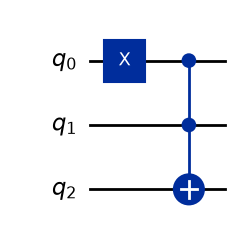

In [27]:
circuit = QuantumCircuit(3)
circuit.x(0)
circuit.ccx(0,1,2) #(Control, Control, Target)
circuit.draw(output='mpl')

In [28]:
simulator = Aer.get_backend('statevector_simulator')
compiled = transpile(circuit, simulator)
result = simulator.run(compiled).result()
statevector = result.get_statevector()
array_to_latex(statevector)

<IPython.core.display.Latex object>

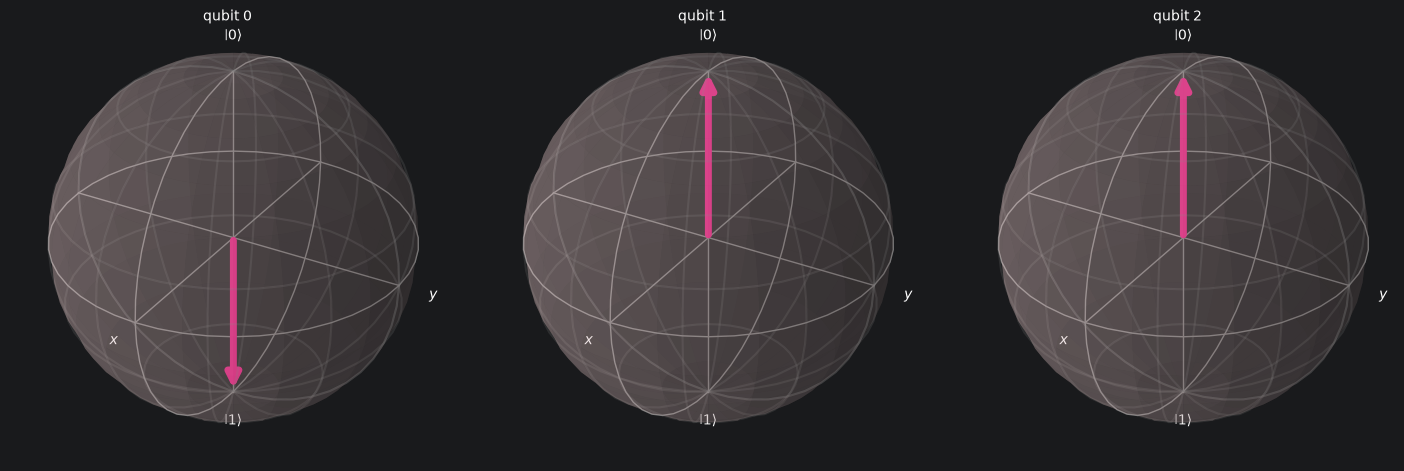

In [29]:
plot_bloch_multivector(statevector)

The target is not flipped because both control bits are not one. To flip the target I will insert another X-Gate in front of the second control bit

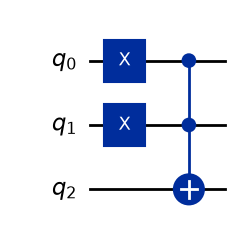

In [30]:
circuit = QuantumCircuit(3)
circuit.x(0)
circuit.x(1)
circuit.ccx(0,1,2) #(Control, Control, Target)
circuit.draw(output='mpl')

In [31]:
circuit.draw(output='mpl')
simulator = Aer.get_backend('statevector_simulator')
compiled = transpile(circuit, simulator)
result = simulator.run(compiled).result()
statevector = result.get_statevector()
array_to_latex(statevector)

<IPython.core.display.Latex object>

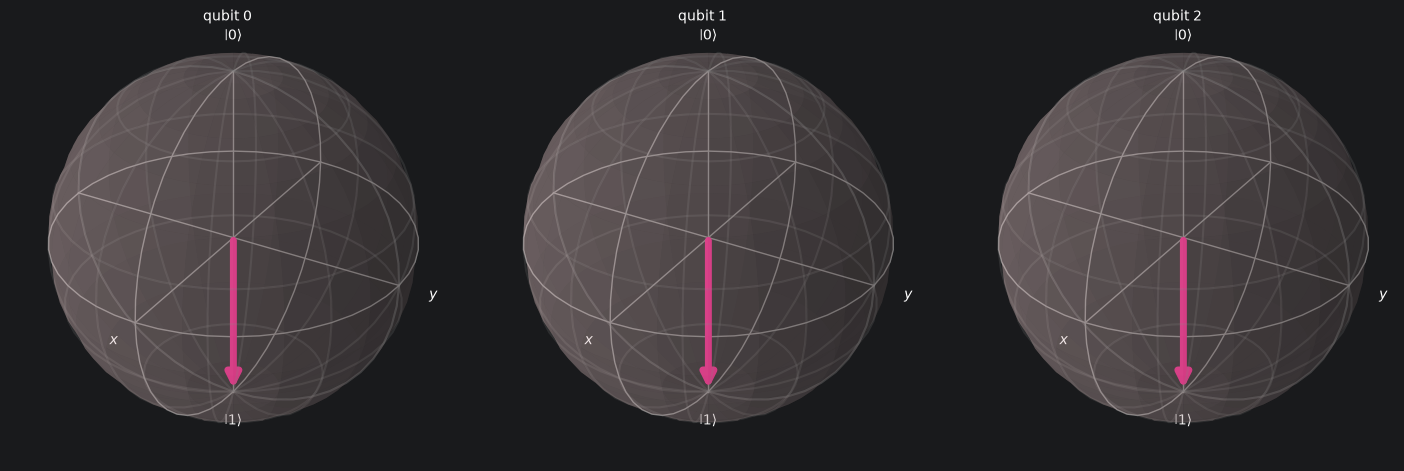

In [32]:
plot_bloch_multivector(statevector)

Since both controls are 1 the target gets flipped ending up in the 1 state.